<img src="https://drive.google.com/uc?id=1pywV57mRvieCmWVg-xYxKarofyPi5Pnh" style="width:100%;"/>

<img src="https://drive.google.com/uc?id=1843RwajjhBxkVDqjGIV3QNkbq9Eroeu5" style="width:100%;"/>

In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATASET_NAME = "cifar10"   # "mnist" | "fashion_mnist" | "cifar10"

BATCH_SIZE = 256
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-5
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

VAL_RATIO = 0.1
DATA_ROOT = "./data"
CKPT_PATH = f"conv_autoencoder_{DATASET_NAME}.pt"

VIS_EVERY = 1           # cada cuántas épocas mostrar reconstrucciones
VIS_N_IMAGES = 10       # cuántas imágenes mostrar


In [4]:
def get_dataset(name: str, root: str):
    name = name.lower().strip()

    if name == "mnist":
        in_channels = 1
        img_size = 28
        transform = transforms.Compose([transforms.ToTensor()])
        train_full = datasets.MNIST(root=root, train=True, download=True, transform=transform)
        test_set   = datasets.MNIST(root=root, train=False, download=True, transform=transform)
        return train_full, test_set, in_channels, img_size

    if name == "fashion_mnist":
        in_channels = 1
        img_size = 28
        transform = transforms.Compose([transforms.ToTensor()])
        train_full = datasets.FashionMNIST(root=root, train=True, download=True, transform=transform)
        test_set   = datasets.FashionMNIST(root=root, train=False, download=True, transform=transform)
        return train_full, test_set, in_channels, img_size

    if name == "cifar10":
        in_channels = 3
        img_size = 32
        transform = transforms.Compose([transforms.ToTensor()])
        train_full = datasets.CIFAR10(root=root, train=True, download=True, transform=transform)
        test_set   = datasets.CIFAR10(root=root, train=False, download=True, transform=transform)
        return train_full, test_set, in_channels, img_size

    raise ValueError("DATASET_NAME debe ser: 'mnist', 'fashion_mnist' o 'cifar10'")

train_full, test_set, IN_CHANNELS, IMG_SIZE = get_dataset(DATASET_NAME, DATA_ROOT)

val_len = int(len(train_full) * VAL_RATIO)
train_len = len(train_full) - val_len
train_set, val_set = random_split(train_full, [train_len, val_len], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Dataset:", DATASET_NAME)
print("IN_CHANNELS:", IN_CHANNELS, "| IMG_SIZE:", IMG_SIZE)
print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))


Dataset: cifar10
IN_CHANNELS: 3 | IMG_SIZE: 32
Train: 45000 Val: 5000 Test: 10000


In [5]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels: int, img_size: int, latent_channels: int = 64):
        super().__init__()
        self.in_channels = in_channels
        self.img_size = img_size

        if img_size == 28:
            self.enc = nn.Sequential(
                nn.Conv2d(in_channels, 56, 3, 2, 1),
                nn.ReLU(inplace=True),
                nn.Conv2d(56, 112, 3, 2, 1),
                nn.ReLU(inplace=True),
                nn.Conv2d(112, latent_channels, 3, 2, 1),
                nn.ReLU(inplace=True),
            )
            self.dec = nn.Sequential(
                nn.ConvTranspose2d(latent_channels, 112, 4, 2, 1),
                nn.ReLU(inplace=True),
                nn.ConvTranspose2d(112, 56, 4, 2, 1),
                nn.ReLU(inplace=True),
                nn.ConvTranspose2d(56, in_channels, 4, 2, 1),
                nn.Sigmoid(),
            )


        elif img_size == 32:
            self.enc = nn.Sequential(
                nn.Conv2d(in_channels, 64, 4, 2, 1),
                nn.ReLU(inplace=True),
                nn.Conv2d(64, 128, 4, 2, 1),
                nn.ReLU(inplace=True),
                nn.Conv2d(128, latent_channels, 4, 2, 1),
                nn.ReLU(inplace=True),
            )
            self.dec = nn.Sequential(
                nn.ConvTranspose2d(latent_channels, 128, 4, 2, 1),
                nn.ReLU(inplace=True),
                nn.ConvTranspose2d(128, 64, 4, 2, 1),
                nn.ReLU(inplace=True),
                nn.ConvTranspose2d(64, in_channels, 4, 2, 1),
                nn.Sigmoid(),
            )
        else:
            raise ValueError("Soporta img_size 28 (MNIST/FashionMNIST) o 32 (CIFAR10).")

    def forward(self, x):
        z = self.enc(x)
        x_hat = self.dec(z)
        return x_hat, z

model = ConvAutoencoder(in_channels=IN_CHANNELS, img_size=IMG_SIZE, latent_channels=128).to(device)
print(model)


ConvAutoencoder(
  (enc): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
  )
  (dec): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


<img src="https://drive.google.com/uc?id=1IeJGxtIfRegx66lMbkXOkUW86EG7IDht" style="width:100%;"/>

In [6]:
model.dec

Sequential(
  (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (5): Sigmoid()
)

In [7]:
3*32*32

3072

In [8]:
32*4*4

512

In [9]:
import numpy as np

def _to_img_grid(x_np: np.ndarray):
    if x_np.shape[1] == 1:
        return [x_np[i, 0] for i in range(x_np.shape[0])], True
    return [np.transpose(x_np[i], (1,2,0)) for i in range(x_np.shape[0])], False

def show_reconstructions_epoch(loader, epoch: int, n_images: int = 10):
    model.eval()

    x, _ = next(iter(loader))
    x = x[:n_images].to(device)

    with torch.no_grad():
        x_hat, _ = model(x)

    x_np = x.detach().cpu().numpy()
    x_hat_np = x_hat.detach().cpu().numpy()

    x_imgs, is_gray = _to_img_grid(x_np)
    xhat_imgs, _ = _to_img_grid(x_hat_np)

    plt.figure(figsize=(n_images * 1.2, 2.8))
    plt.suptitle(f"Época {epoch} | Arriba: original | Abajo: reconstrucción", y=1.02)

    for i in range(n_images):
        plt.subplot(2, n_images, i + 1)
        if is_gray:
            plt.imshow(x_imgs[i], cmap="gray")
        else:
            plt.imshow(x_imgs[i])
        plt.axis("off")

    for i in range(n_images):
        plt.subplot(2, n_images, n_images + i + 1)
        if is_gray:
            plt.imshow(xhat_imgs[i], cmap="gray")
        else:
            plt.imshow(xhat_imgs[i])
        plt.axis("off")

    plt.show()


In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    n = 0

    for x, _ in loader:
        x = x.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        x_hat, _ = model(x)
        loss = criterion(x_hat, x)

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        n += bs

    return total_loss / max(n, 1)

best_val = float("inf")
history = {"train": [], "val": []}

# Concepto: fijamos un mini lote "testigo" al inicio para comparar siempre lo mismo
fixed_batch, _ = next(iter(val_loader))
fixed_batch = fixed_batch[:VIS_N_IMAGES].to(device)

def show_fixed_reconstructions(epoch: int):
    model.eval()
    with torch.no_grad():
        x_hat, _ = model(fixed_batch)

    x_np = fixed_batch.detach().cpu().numpy()
    x_hat_np = x_hat.detach().cpu().numpy()

    x_imgs, is_gray = _to_img_grid(x_np)
    xhat_imgs, _ = _to_img_grid(x_hat_np)

    plt.figure(figsize=(VIS_N_IMAGES * 1.2, 2.8))
    plt.suptitle(f"Época {epoch} | Misma entrada fija en cada época", y=1.02)

    for i in range(VIS_N_IMAGES):
        plt.subplot(2, VIS_N_IMAGES, i + 1)
        if is_gray:
            plt.imshow(x_imgs[i], cmap="gray")
        else:
            plt.imshow(x_imgs[i])
        plt.axis("off")

    for i in range(VIS_N_IMAGES):
        plt.subplot(2, VIS_N_IMAGES, VIS_N_IMAGES + i + 1)
        if is_gray:
            plt.imshow(xhat_imgs[i], cmap="gray")
        else:
            plt.imshow(xhat_imgs[i])
        plt.axis("off")

    plt.show()

# Concepto: antes de entrenar, vemos cómo reconstruye "sin haber aprendido"
show_fixed_reconstructions(epoch=0)

for epoch in range(1, EPOCHS + 1):
    # Concepto: el modelo intenta reconstruir, y el error guía qué información debe preservar mejor
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    # Concepto: guardamos el mejor estado según validación para quedarnos con la mejor generalización
    if val_loss < best_val:
        best_val = val_loss
        torch.save(
            {
                "model_state": model.state_dict(),
                "epoch": epoch,
                "val_loss": val_loss,
                "dataset": DATASET_NAME,
                "in_channels": IN_CHANNELS,
                "img_size": IMG_SIZE,
            },
            CKPT_PATH,
        )

    print(f"Epoch {epoch:02d}/{EPOCHS} | train MSE: {train_loss:.6f} | val MSE: {val_loss:.6f} | best val: {best_val:.6f}")

    # Concepto: mirar la evolución visual ayuda a entender qué "estructura" está aprendiendo a conservar
    if (epoch % VIS_EVERY) == 0:
        show_fixed_reconstructions(epoch=epoch)

print("Checkpoint guardado en:", CKPT_PATH)


Output hidden; open in https://colab.research.google.com to view.

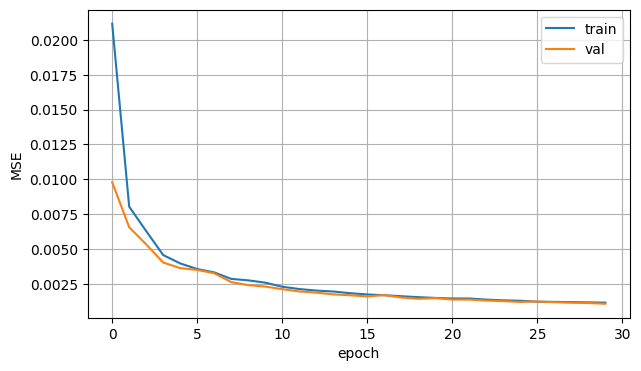

In [11]:
plt.figure(figsize=(7,4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


Test MSE: 0.0010514451365917922


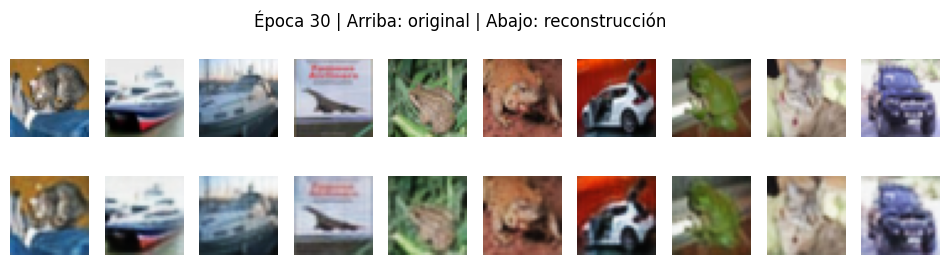

In [16]:
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

test_loss = 0.0
n = 0
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device, non_blocking=True)
        x_hat, _ = model(x)
        loss = criterion(x_hat, x)
        bs = x.size(0)
        test_loss += loss.item() * bs
        n += bs

test_loss /= max(n, 1)
print("Test MSE:", test_loss)

# Concepto: al final, miramos reconstrucciones sobre datos nunca vistos para validar generalización
show_reconstructions_epoch(test_loader, epoch=ckpt["epoch"], n_images=VIS_N_IMAGES)
